In [2]:
# Code example
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Direct raw link to the dataset
url = 'https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/main/day25-normalization/wine_data.csv'

df = pd.read_csv(url,header = None, usecols = [0,1,2])
df.columns = ['class label', 'alcohol', 'malic acid']


In [32]:
df

,class label,alcohol,malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='alcohol', ylabel='Density'>

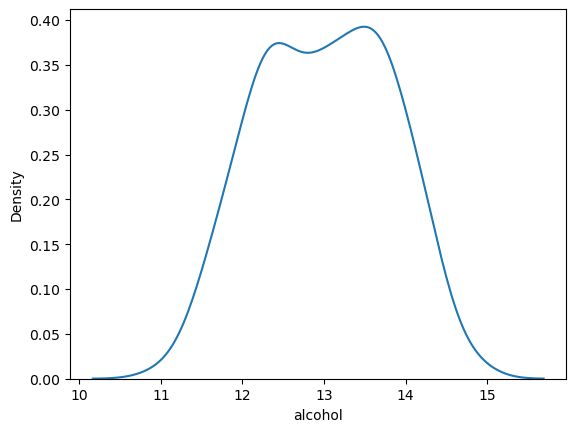

In [27]:
sns.kdeplot(df['alcohol'])


# 1. KDE Plot
# It does the exact same thing as a histogram, but instead of using blocks/bins, it creates a smooth, continuous density slope (a line).

# how to read 
# Instead of looking at a bar, you look at the peak of the wave. If the curve is high over the 12 to 14 range
# it means most of your data is crowded right there.
    
# 2. Histogram
# It separates the data ranges into bins (like 0 to 15, 10 to 30).

# How to read: It shows the frequency or density of people lying in that range using solid bars




<Axes: xlabel='alcohol', ylabel='malic acid'>

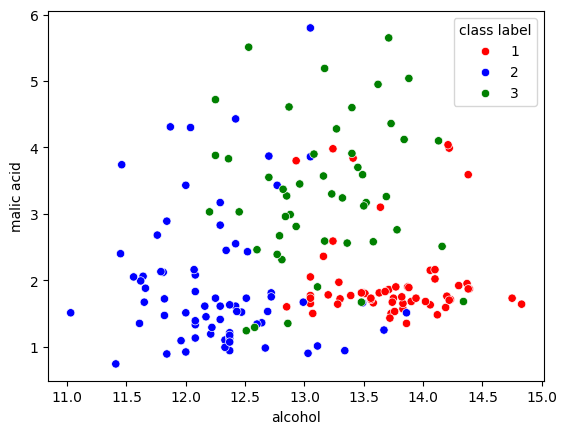

In [29]:
color_dict = {1:'red', 2:'blue', 3:'green'}
sns.scatterplot(data = df, x ='alcohol', y='malic acid',hue='class label',palette = color_dict)

In [31]:
# step 1: Look at the X-axis (The Bottom)
# What it is: This is the alcohol level. It goes from 11.0 to 15.0.

# How to read it: Moving from left to right means the alcohol level is increasing.

# Step 2: Look at the Y-axis (The Left Side)
# What it is: This is the malic acid level. It goes from 1 to 6.

# How to read it: Moving from bottom to top means the amount of malic acid is increasing.

# Step 3: Look at the Colors (The Legend)
# Your code color-coded the dots into 3 separate groups based on their class label:

# Red dots = Class 1

# Blue dots = Class 2

# Green dots = Class 3

# Now, put it all together to read the patterns::

# Class 2 (Blue Dots) is on the bottom-left: * This means Class 2 samples have low alcohol (mostly 11.5 to 13) and low malic acid (mostly under 3).

# Class 1 (Red Dots) is on the bottom-right: * This means Class 1 samples have high alcohol (mostly 13 to 14.5) but still have low malic acid (around 1.5 to 2.5).

# Class 3 (Green Dots) is at the top-middle/right: * This means Class 3 samples stand out because they have much higher malic acid (ranging from 3 all the way up to 6) compared to the other two classes.

# summary
# Scatter Plot Reading:
# Look at where the colored dots cluster. It shows that Blue has low alcohol + low acid, Red has high alcohol + low acid, and Green has high acid.
    

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df.drop('class label',axis = 1),
                                                 df['class label'], 
                                                 test_size = 0.3,
                                                 random_state = 0)



# so here we are  using model selection library in sicitlearn and importing train test split  from it

# df.drop('class label') creates a temporary copy of the inputs without the output column. 
# This passes the features to the split while keeping our original 'df' completely safe and unchanged.

# df['class label'] points directly to the location of the real target column without making a copy.

# we are deciding test size that we want to take here we are taking 30 percent 

# use of random state:
# Without random_state: The data shuffles differently every time you hit run. The training rows change, so the accuracy changes.

# With random_state = 0: It locks the shuffle sequence. Every time you run it, it picks the exact same rows for training so your results don't change.

In [10]:
x_train.shape , x_test.shape

((124, 2), (54, 2))

In [11]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()


# after train test split whenever we we fit we always fit on training data but transformboth training and test
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

# when we use sickitlearn classes it converts our data into numpy array

In [ ]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns = x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns = x_train.columns)


In [14]:
np.round(x_train.describe(),1)

,alcohol,malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [16]:
np.round(x_train_scaled.describe(),1)

,alcohol,malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


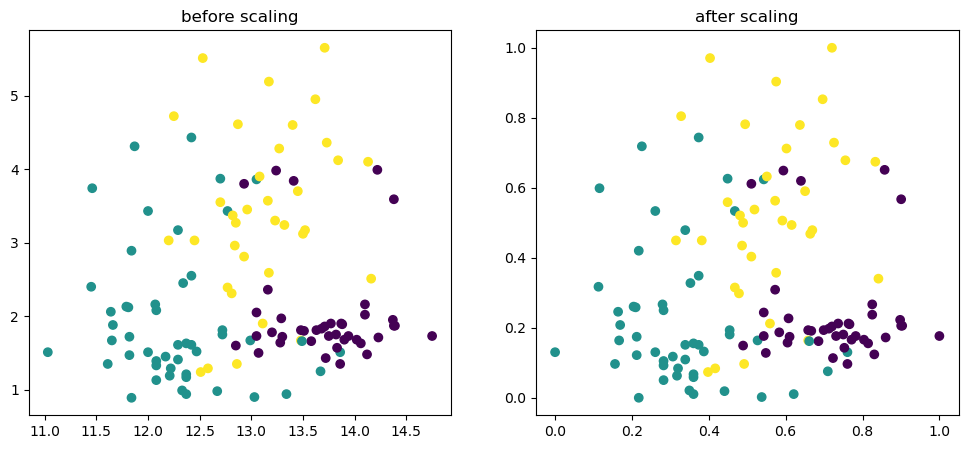

In [28]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize=(12,5))

ax1.scatter(x_train['alcohol'], x_train['malic acid'], c = y_train)
ax1.set_title("before scaling")

ax2.scatter(x_train_scaled['alcohol'], x_train_scaled['malic acid'], c = y_train)
ax2.set_title("after scaling")

plt.show()





#Everything is same but  this is 2d this is  squeshing data into unit rectangle 

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize=(12,5))

# before scaling
ax1.set_title("before scaling")
sns.kdeplot(x_train['alcohol'],ax = ax1)
sns.kdeplot(x_train['malic acid'], ax = ax1)


# After scaling
ax2.set_title("after standard scaling")
sns.kdeplot(x_train_scaled['alcohol'],ax = ax2)
sns.kdeplot(x_train_scaled['malic acid'], ax = ax2)

# Mean normalization

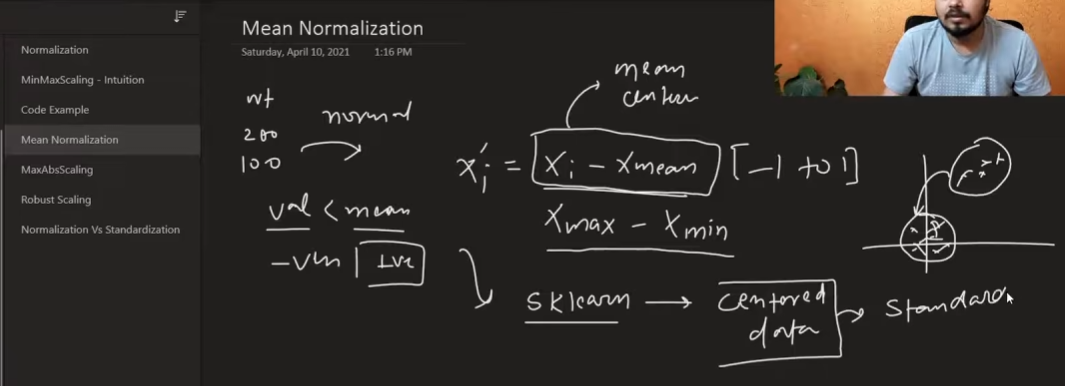

here simply we are centring our mean same like standardization and we get values
in the range of [-1 to 1]


formula = x' = xi-xmean/xmax-xmin

it is used very less people prefer standardization


# MaxAbsScaling

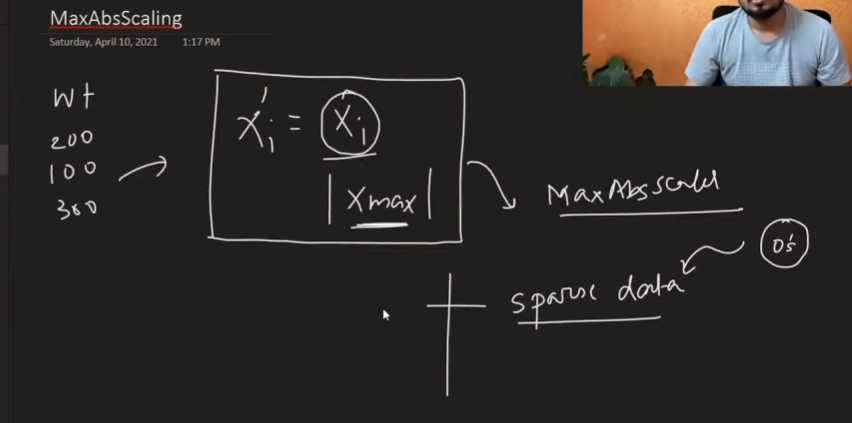

when we have many zeroes(sparst data) we use this
formula = x' = xi/|Xmax|


# Robust Scaling

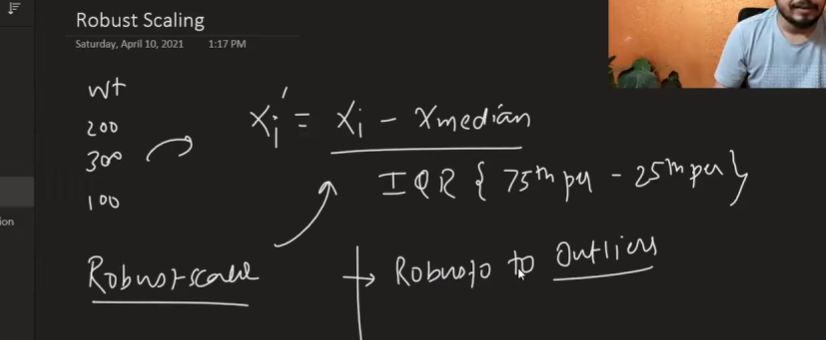

if our data has many outliers then it will perform better

# when to use normalization  and standardization


first of all ask :
is feature scaling required

* in most of the places standardizaiton is used
* if u have no idea then use standardization
* if u know there are outliers then robust scaling
* sparst data then maxabs scaling
* if u know the min and max of ur given data then use MinMax scaler